In [ ]:
from typing import List, Optional, TypedDict,  Annotated 
from pydantic import BaseModel, Field 

class Experience(BaseModel):
    role: str = Field(description = "job title or role")
    company: str = Field(description = "Company") 
    start_date:Optional [str] = Field(default = None, description= "Start Date(e.g., 'jan 2020')") 
    end_date: Optional [str] = Field (default = None, description = "End date(e.g., 'present')") 
    responsiblities: List [str] = Field(default_factory = list, description ="list of duties or bullet points.") 
    achievements: list [str] = Field (default_factory = list, description = "Quantifiable achievements (e.g., 'Increased sales by 20%/n')") 


class Education(BaseModel): 
    degree: str = Field(description = "Degree name(e.g, 'Bachelor of arts')") 
    institution: str = Field(description = "school or university") 
    state_date: Optional [str] = Field(default = None, description ="Start date") 
    end_date : Optional [str] = Field(default = None, description = "End date or graduation year.") 
    details: list [str] = Field(default_factory= List, description ="Relevant coursework, GPA, Honours,") 

class SkillCategory (BaseModel):
    category: Optional [str] = Field (default = None, description = "category name of the skill(e.g., 'softskills')")
    skills: List [str] = Field(description = "List of skills under each Category") 

class Project(BaseModel):
    name: str = Field (description = "project Title") 
    description: List [str] = Field( description = "Details or achievement in the project") 

class Certification (BaseModel):
    name: str = Field( description = "Certification name") 
    issuer: Optional [str] = Field (default = None, description = "issuing organization")
    date: Optional [str] = Field(default = None, description = "issue or expiration date") 

class ResumeSchema(BaseModel):
    summary: Optional [str] = Field (default = None, description = "professional summary or objective.") 
    work_experience: List [Experience] = Field (default_factory = list, description = "list of work experiences.") 
    education: List [Education] = Field (default_factory = list, description = "list of educational qualification.") 
    skills: List [SkillCategory] = Field (default_factory = list, description ="categorized or flat list of skils") 
    achievements: list [str] = Field (default_factory=  list, description = "Standalone description") 
    projects: List [Project] = Field (default_factory = list, description = "list of projects") 
    certification: list [Certification] = Field(default_factory= list, description = " list of certification") 
    other_sections: dict = Field (default_factory = dict, description = "Any other parsed session, (e,g, {'volunteer'})") 
    keyword: List [str] = Field(default_factory = List, description = "Extracted high frequency keywords.")



In [2]:
ResumeSchema.model_json_schema()

{'$defs': {'Certification': {'properties': {'name': {'description': 'Certification name',
     'title': 'Name',
     'type': 'string'},
    'issuer': {'anyOf': [{'type': 'string'}, {'type': 'null'}],
     'default': None,
     'description': 'issuing organization',
     'title': 'Issuer'},
    'date': {'anyOf': [{'type': 'string'}, {'type': 'null'}],
     'default': None,
     'description': 'issue or expiration date',
     'title': 'Date'}},
   'required': ['name'],
   'title': 'Certification',
   'type': 'object'},
  'Education': {'properties': {'degree': {'description': "Degree name(e.g, 'Bachelor of arts')",
     'title': 'Degree',
     'type': 'string'},
    'institution': {'description': 'school or university',
     'title': 'Institution',
     'type': 'string'},
    'state_date': {'anyOf': [{'type': 'string'}, {'type': 'null'}],
     'default': None,
     'description': 'Start date',
     'title': 'State Date'},
    'end_date': {'anyOf': [{'type': 'string'}, {'type': 'null'}],
 

In [3]:
from typing import List, Optional, TypedDict, Annotated 
from pydantic import BaseModel, Field 

class Responsibility(BaseModel):
    description: str = Field(description = "Title of the position") 

class Requirement(BaseModel):
    description: str = Field(description = "required skills, experience or qualifications(e.g., '5+ years in sales marketing')") 
    category: Optional [str] = Field (default = None, description = "category (e.g, 'skills', 'Education')") 

class Preferred(BaseModel): 
    description: str = Field (description = "Nice-to-have(e.g, 'Experience with adobe suite')") 

class JDSchema(BaseModel):
    job_Title: str = Field(description ="Title of the position") 
    company: Optional [str] = Field(default = None, description = "Company Name") 
    overview:Optional [str] = Field(default = None, description ="job summary or purpose") 
    responsibilities: list [Responsibility] = Field(default_factory= list, description = "list of the duties.") 
    requirements: list [Requirement] = Field (default_factory = List, description = "Must have quqlification") 
    preferred: list [Preferred] = Field(default_factory = List, description ="preferred skills or trait") 
    company_values: list [str] = Field (default_factory = List, description = "Extracted values (e,g, 'Innovation','baking')") 
    keywords: list [str] = Field(default_factory = list, description = "key terms for matching (e.g, 'SEO', 'Leadership')" ) 
    other_details: dict = Field(default_factory = dict, description = "Any additional info(e.g, 'remote jobs', 'location')") 




In [4]:
JDSchema.model_json_schema()

{'$defs': {'Preferred': {'properties': {'description': {'description': "Nice-to-have(e.g, 'Experience with adobe suite')",
     'title': 'Description',
     'type': 'string'}},
   'required': ['description'],
   'title': 'Preferred',
   'type': 'object'},
  'Requirement': {'properties': {'description': {'description': "required skills, experience or qualifications(e.g., '5+ years in sales marketing')",
     'title': 'Description',
     'type': 'string'},
    'category': {'anyOf': [{'type': 'string'}, {'type': 'null'}],
     'default': None,
     'description': "category (e.g, 'skills', 'Education')",
     'title': 'Category'}},
   'required': ['description'],
   'title': 'Requirement',
   'type': 'object'},
  'Responsibility': {'properties': {'description': {'description': 'Title of the position',
     'title': 'Description',
     'type': 'string'}},
   'required': ['description'],
   'title': 'Responsibility',
   'type': 'object'}},
 'properties': {'job_Title': {'description': 'Title 

In [5]:
import os 
from dotenv import load_dotenv 
load_dotenv() 
from langchain_groq import ChatGroq 
from langchain_core.prompts import ChatPromptTemplate 
from langgraph.graph import StateGraph, START, END 
from langchain_core.messages import SystemMessage, HumanMessage 

llm = ChatGroq(model= "openai/gpt-oss-120b", api_key =os.getenv("GROQ_API_KEY")) 

In [6]:
resumePrompt = """ 
 You are an expert resume parser. your task is to extract structured information from provided resume text. 
 - Be accurate and only use information explicitely from the text. 
 - Quantify achievements where possible (e.g, "increased sales by 20%") 
 - categorized skills logically if not already categorized. 
 - Extract keywords as high frequency terms relevant to skills/experiences.
 - if a section is missing use empty  list or null.
 output only the json matching this schema(no extra text) :
 {schema}
"""

jdPrompt = """" 
You are an expert job description parser. your job is to extract structured information from the provided job description text. 
- identify must have requiremwents and nice to have separately.
- Extract responsibilities as bullet-like descriptions. 
- pull keywords for ATs matching(Tools, skills, Traits) 
- capture company values if mentioned. 
- be precise and coincise. 
output only the json matching this schema(no extra text): 
{schema}
"""

In [7]:
resume_llm = llm.with_structured_output(ResumeSchema)
jd_llm = llm.with_structured_output(JDSchema) 

In [8]:
class AnalyzerState(TypedDict):
    resume_text: str 
    jd_text: str 
    parsed_resume: ResumeSchema 
    parsed_jd: JDSchema 
    

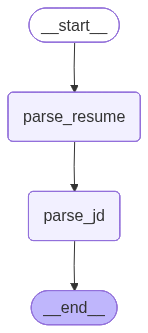

In [9]:
def parseResumeNode (state: AnalyzerState) -> AnalyzerState:
    sys_msg = SystemMessage (content=resumePrompt.format(schema=ResumeSchema.model_json_schema()))
    msg = HumanMessage (content=f"Resume text:\n\n{state['resume_text']}")

    response = resume_llm.invoke ([sys_msg, msg])
    return {'parsed_resume': response}

def parseJdNode (state:AnalyzerState) -> AnalyzerState:
    sys_msg = SystemMessage (content=jdPrompt.format(schema=JDSchema.model_json_schema()))
    msg = HumanMessage (content=f"Job Description text:\n\n{state['jd_text']}")

    response = jd_llm.invoke ([sys_msg, msg])
    return {'parsed_jd':response}

analyzer_builder = StateGraph(state_schema=AnalyzerState)

analyzer_builder.add_node("parse_resume", parseResumeNode)
analyzer_builder.add_node("parse_jd", parseJdNode)

# Edges: Run resume parsing first, then JD (order doesn't matter much, but sequential for simplicity)
analyzer_builder.add_edge(START, "parse_resume")
analyzer_builder.add_edge("parse_resume", "parse_jd")
analyzer_builder.add_edge("parse_jd", END)

analyzer_graph = analyzer_builder.compile ()
from IPython.display import display, Image

display (Image (analyzer_graph.get_graph().draw_mermaid_png()))

In [10]:
jd = """ 
job Title: Ai engineer.
Company: NeuroTech innovation LImited.
Location: Lagos, Nigeria(Hybrid/remote options.)
Department: Ai and data science. 
Employment Type: Full-Time. 
Salary_Range: $100,000-$200,000 per annum (comensurate with experience) + benefits. 
posted: Jan 2026 
Job Interview: 
NeuroTech is a Ai driven Startup in Nigeria, specializing in solutions relating to Healthcare, Agriculture and Finance. We are seeking a passionate ai engineer to join our team. 
Key Responsibilities: 
Design, develop and deploy machine learning models, including LLM, predictive models, computer vision to solve using framework, pytorch, tensorflow, scikit-learn. 
optimize ai pipelines for production, focusing on efficiency,scalability and edge deployment.(e.g, via kubernates, docker, AWS/GCP). 
conduct experiements with generative Ai(e.g, diffusion models, GANs) and multimodal systems to solve domain specific challenges. 
Implement ethical ai challenges including bias detection, explanability, and compliance with regulations like nigeria protection acts. 
Collaborate with data-engineers, and product teams to integrate ai into applications.performing a/b testing and performance monitoring. 
mentor junior engineers and participate in code reviews, ensuring best practices in MLops.
REQUIREMENTS: 
Batchelors or masters degree in computer science, Ai, DataScience or related field.
3+ 0n hands on experience in AI/ML engineering. 
Proficiency in python and machine learning library. 
strong understanding of deep learning achitectures, NLP, and computer visions. 
Experience with cloud platforms(AWS, AZURE, GCP) and containerization(docker).  
familiarity with big data tools(spark) and version control. 
Excellent problem solving skills and ability to work in agile enviroments.  
preferred: Certifications in AWS ML specialty or publication Ai conferences.

Nice to have:
Experience in Africa centric ai applications(e.g, multilingual models for local languages.) 
Knowledge  of reinforcement learning and Ai for sustainability. 
open source contribution or hackathon wins. 

What we offer:
Competitve salary and and equity options. 
Health insurance and paid time-off. 
flexible with work environment for remote opportutnities. 
chance to work in impactful projects in a diverse teams.  

To apply, submit your resume and a cover letter highlighting your Ai projects to careers@neuroTech.ng. We are an equal opporturnity enployer.




"""

In [11]:
from pypdf import PdfReader 
path = "Resume/Resume.pdf" 
resume = ""
reader = PdfReader(path) 
resume = "\n".join(page.extract_text() or "" for page in reader.pages)

In [12]:
print(resume)

Felix Adebayo Lagos, Lagos, Nigeria | felix.adebayo@email.com | +234-123-456-7890 | 
linkedin.com/in/felix-adebayo-ai | github.com/felixadebayo 
Professional Summary 
Dynamic AI Engineer with 5+ years of experience designing, developing, and deploying machine 
learning models and AI systems. Expertise in generative AI, natural language processing (NLP), 
computer vision, and ethical AI frameworks. Proven track record in optimizing models for 
production, collaborating on cross-functional teams, and driving business impact through data-
driven solutions. Passionate about leveraging AI for sustainable development in emerging 
markets like Nigeria. 
Skills 
• Programming & Frameworks: Python, Java, PyTorch, TensorFlow, Scikit-learn, Hugging 
Face Transformers, LangChain, Keras 
• AI/ML Specialties: Deep Learning, NLP (e.g., LLMs like GPT-4, Llama), Computer Vision 
(OpenCV), Reinforcement Learning, Generative AI (GANs, Diffusion Models) 
• Tools & Platforms: AWS SageMaker, Google Cloud AI

In [13]:
resume

'Felix Adebayo Lagos, Lagos, Nigeria | felix.adebayo@email.com | +234-123-456-7890 | \nlinkedin.com/in/felix-adebayo-ai | github.com/felixadebayo \nProfessional Summary \nDynamic AI Engineer with 5+ years of experience designing, developing, and deploying machine \nlearning models and AI systems. Expertise in generative AI, natural language processing (NLP), \ncomputer vision, and ethical AI frameworks. Proven track record in optimizing models for \nproduction, collaborating on cross-functional teams, and driving business impact through data-\ndriven solutions. Passionate about leveraging AI for sustainable development in emerging \nmarkets like Nigeria. \nSkills \n• Programming & Frameworks: Python, Java, PyTorch, TensorFlow, Scikit-learn, Hugging \nFace Transformers, LangChain, Keras \n• AI/ML Specialties: Deep Learning, NLP (e.g., LLMs like GPT-4, Llama), Computer Vision \n(OpenCV), Reinforcement Learning, Generative AI (GANs, Diffusion Models) \n• Tools & Platforms: AWS SageMaker, 

In [14]:
result = analyzer_graph.invoke(input = {"jd_text": jd, "resume_text": resume}) 

In [15]:
result

{'resume_text': 'Felix Adebayo Lagos, Lagos, Nigeria | felix.adebayo@email.com | +234-123-456-7890 | \nlinkedin.com/in/felix-adebayo-ai | github.com/felixadebayo \nProfessional Summary \nDynamic AI Engineer with 5+ years of experience designing, developing, and deploying machine \nlearning models and AI systems. Expertise in generative AI, natural language processing (NLP), \ncomputer vision, and ethical AI frameworks. Proven track record in optimizing models for \nproduction, collaborating on cross-functional teams, and driving business impact through data-\ndriven solutions. Passionate about leveraging AI for sustainable development in emerging \nmarkets like Nigeria. \nSkills \n• Programming & Frameworks: Python, Java, PyTorch, TensorFlow, Scikit-learn, Hugging \nFace Transformers, LangChain, Keras \n• AI/ML Specialties: Deep Learning, NLP (e.g., LLMs like GPT-4, Llama), Computer Vision \n(OpenCV), Reinforcement Learning, Generative AI (GANs, Diffusion Models) \n• Tools & Platforms:

In [16]:
result["parsed_resume"].model_dump()

{'summary': 'Dynamic AI Engineer with 5+ years of experience designing, developing, and deploying machine learning models and AI systems. Expertise in generative AI, natural language processing (NLP), computer vision, and ethical AI frameworks. Proven track record in optimizing models for production, collaborating on cross-functional teams, and driving business impact through data-driven solutions. Passionate about leveraging AI for sustainable development in emerging markets like Nigeria.',
 'work_experience': [{'role': 'AI Engineer',
   'company': 'TechInnovate Nigeria Ltd., Lagos, Nigeria',
   'start_date': 'June 2023',
   'end_date': 'Present',
   'responsiblities': ['Developed and deployed a generative AI chatbot using LangChain and Grok models, reducing customer support response time by 40% and handling 10,000+ queries monthly.',
    'Optimized NLP models for sentiment analysis on social media data (X/Twitter feeds), improving accuracy from 78% to 92% via fine-tuning with Hugging

In [17]:
result["parsed_jd"].model_dump()

{'job_Title': 'AI Engineer',
 'company': 'NeuroTech Innovation Limited',
 'overview': 'NeuroTech is an AI‑driven startup in Nigeria specializing in healthcare, agriculture, and finance solutions. The company seeks a passionate AI engineer to join the team.',
 'responsibilities': [{'description': 'Design, develop and deploy machine learning models, including LLMs, predictive models, and computer vision using frameworks such as PyTorch, TensorFlow, and scikit‑learn.'},
  {'description': 'Optimize AI pipelines for production with a focus on efficiency, scalability, and edge deployment via Kubernetes, Docker, and cloud platforms (AWS/GCP).'},
  {'description': 'Conduct experiments with generative AI (e.g., diffusion models, GANs) and multimodal systems to address domain‑specific challenges.'},
  {'description': 'Implement ethical AI practices, including bias detection, explainability, and compliance with regulations like Nigeria’s data protection acts.'},
  {'description': 'Collaborate wit

In [18]:
from typing import List, Optional
from pydantic import BaseModel, Field

class MatchItem(BaseModel):
    jd_element: str = Field(description="Phrase or requirement from the JD (e.g. 'experience with LLMs', 'deploy models to production')")
    jd_category: Optional[str] = Field(default=None, description="Category e.g. 'Technical Skills', 'Experience', 'Soft Skills'")
    resume_evidence: str = Field(description="Relevant excerpt / achievement / bullet from resume")
    resume_section: str = Field(description="Which resume section this comes from: 'summary', 'work_experience', 'skills', 'projects', etc.")
    strength_score: float = Field(description="Match strength 0.0–1.0", ge=0.0, le=1.0)
    explanation: str = Field(description="Short reasoning why this is a good match")
    suggested_phrasing: str = Field(description="Suggested 1–2 sentence way to mention this in cover letter")

class MatchMap(BaseModel):
    overall_match_score: float = Field(description="Overall estimated fit 0–100", ge=0, le=100)
    top_matches: List[MatchItem] = Field(description="Top 4–8 strongest matches, sorted by strength descending")
    gaps: List[str] = Field(default_factory=list, description="Important JD requirements with no/weak match in resume")
    keyword_overlap: List[str] = Field(default_factory=list, description="JD keywords that appear in resume")
    keyword_missing: List[str] = Field(default_factory=list, description="Important JD keywords not found in resume")

In [19]:
matcher_system_prompt = """You are an expert career coach and ATS optimization specialist.
Your task is to compare a parsed resume with a parsed job description and create a precise, honest match map.

Rules:
- Be realistic — do NOT inflate matches or hallucinate evidence.
- Only use information that actually exists in the resume.
- Prioritize **quantifiable achievements** and **specific tools/technologies** when matching technical requirements.
- For soft skills, look for behavioral evidence (leadership, collaboration, etc.).
- Score strength realistically:
  0.0–0.3 = weak / tangential
  0.4–0.6 = moderate / transferable
  0.7–0.85 = strong direct match
  0.86–1.0 = excellent / near-perfect match
- Select the **4–8 strongest** matches only — quality > quantity.
- Identify real gaps (important JD items with little/no coverage).
- Suggest natural, concise phrasing the candidate could use in a cover letter.

Output **only** valid JSON matching this schema — no extra text, comments, or markdown:

{schema}
"""

matcher_user_prompt = """Parsed Resume:
{parsed_resume}

Parsed Job Description:
{parsed_jd}

Create the MatchMap now."""

In [20]:
matcher_llm = llm.with_structured_output (MatchMap)

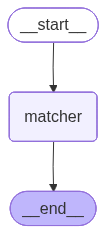

In [21]:
from typing import TypedDict

class CoverLetterState(TypedDict):
    resume_text: str
    jd_text: str
    parsed_resume: dict          # or ResumeSchema
    parsed_jd: dict              # or JDSchema
    match_map: Optional[MatchMap]

def matcher_node(state: CoverLetterState) -> CoverLetterState:
    """
    Runs the matcher and adds match_map to state
    """
    sys_msg = SystemMessage (content=matcher_system_prompt.format(schema=MatchMap.model_json_schema()))
    msg = HumanMessage (content=matcher_user_prompt.format (parsed_resume=state['parsed_resume'], parsed_jd=state['parsed_jd']))
    response = matcher_llm.invoke ([sys_msg, msg])

    return {"match_map": response}


matcher_builder = StateGraph (CoverLetterState)
matcher_builder.add_node ('matcher', matcher_node)

matcher_builder.add_edge(START, 'matcher')
matcher_builder.add_edge ('matcher', END)

matcher_agent = matcher_builder.compile ()

display (Image (matcher_agent.get_graph ().draw_mermaid_png()))

In [26]:
data = {
    'resume_text': result['resume_text'],
    'jd_text': result['jd_text'],
    'parsed_resume': result['parsed_resume'],
    'parsed_jd': result['parsed_jd']
}
result1 = matcher_agent.invoke (input=data)

In [27]:
result1

{'resume_text': 'Felix Adebayo Lagos, Lagos, Nigeria | felix.adebayo@email.com | +234-123-456-7890 | \nlinkedin.com/in/felix-adebayo-ai | github.com/felixadebayo \nProfessional Summary \nDynamic AI Engineer with 5+ years of experience designing, developing, and deploying machine \nlearning models and AI systems. Expertise in generative AI, natural language processing (NLP), \ncomputer vision, and ethical AI frameworks. Proven track record in optimizing models for \nproduction, collaborating on cross-functional teams, and driving business impact through data-\ndriven solutions. Passionate about leveraging AI for sustainable development in emerging \nmarkets like Nigeria. \nSkills \n• Programming & Frameworks: Python, Java, PyTorch, TensorFlow, Scikit-learn, Hugging \nFace Transformers, LangChain, Keras \n• AI/ML Specialties: Deep Learning, NLP (e.g., LLMs like GPT-4, Llama), Computer Vision \n(OpenCV), Reinforcement Learning, Generative AI (GANs, Diffusion Models) \n• Tools & Platforms:

In [28]:
result1["match_map"].model_dump()

{'overall_match_score': 85.0,
 'top_matches': [{'jd_element': 'Implement ethical AI practices, including bias detection, explainability, and compliance with regulations like Nigeria’s data protection acts.',
   'jd_category': 'Responsibilities',
   'resume_evidence': 'Led ethical AI audits for fintech app deployments, ensuring bias mitigation and compliance with global standards (e.g., EU AI Act equivalents).',
   'resume_section': 'work_experience',
   'strength_score': 0.9,
   'explanation': "The candidate directly led ethical AI audits, addressing bias mitigation and regulatory compliance, which aligns tightly with the JD's ethical AI requirement.",
   'suggested_phrasing': 'I have led ethical AI audits that identified and mitigated bias while ensuring compliance with international and Nigerian data protection regulations.'},
  {'jd_element': 'Design, develop and deploy machine learning models, including LLMs, predictive models, and computer vision using frameworks such as PyTorch, 

In [29]:
from typing import List, Optional
from pydantic import BaseModel, Field

class CoverLetterDraft(BaseModel):
    full_letter: str = Field(description="The complete cover letter text in plain text / markdown format")
    word_count: int = Field(description="Actual word count of the full letter")
    used_keywords: List[str] = Field(default_factory=list, description="Important JD keywords incorporated")
    

class CoverLetterState(TypedDict):
    resume_text: str
    jd_text: str
    parsed_resume: ResumeSchema               # or your ResumeSchema instance
    parsed_jd: JDSchema                    # or JDSchema
    match_map: Optional[MatchMap]          # or MatchMap
    draft_letter: Optional[CoverLetterDraft]

In [30]:
writerPrompt = """
You are an expert technical recruiter and cover letter coach specializing in {job_title} roles.

Your task: Write a high-impact, tailored cover letter using ONLY the provided resume data, job description, and match_map.

Core rules (2025–2026 best practices):
- Length: 250–400 words, aim 300–350.
- Structure:
  1. Opening (1 paragraph): Hook with position/company interest + brief strongest qualifier.
  2. Body (2 paragraphs): Highlight 2–3 strongest matches from the match_map using STAR-like storytelling.
  3. Closing (1 paragraph): Reiterate fit, show enthusiasm for company mission/values, include clear call to action.
- Tone: Professional, confident, enthusiastic, human—avoid generic buzzwords or robotic phrasing.
- Personalization: Reference company name, role titles, and 1–2 JD elements or values.
- ATS-friendly: Naturally weave in keywords from the match_map (especially top_matches).
- Never invent facts; only use resume evidence and match_map phrasing.
- End with professional sign-off (e.g., "Best regards," or "Sincerely").

Output: Only valid JSON matching the exact schema—no extra text, explanations, or markdown outside the JSON.
{schema}
"""

In [31]:
writer_llm = llm.with_structured_output (CoverLetterDraft)

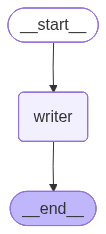

In [32]:
def writer_node (state:CoverLetterState) -> CoverLetterState:
    resume = state['resume_text']
    jd = state['jd_text']
    parsed_resume = state['parsed_resume']
    parsed_jd = state ['parsed_jd']
    match_map = state['match_map']
    job_title = state['parsed_jd'].job_Title

    sys_msg = SystemMessage(content=writerPrompt.format (schema=CoverLetterDraft.model_json_schema(), job_title=job_title))

    msg = HumanMessage (f"""
Parsed Resume:
{parsed_resume}

Parsed JD:
{parsed_jd}

Match Map:
{match_map}

Write the full cover letter
""")
    
    response = writer_llm.invoke (input=[sys_msg, msg])
    return {'draft_letter':response}


writer_builder = StateGraph (CoverLetterState)
writer_builder.add_node ('writer', writer_node)

writer_builder.add_edge(START, 'writer')
writer_builder.add_edge ('writer', END)

writer_agent = writer_builder.compile ()

display (Image (writer_agent.get_graph().draw_mermaid_png()))


In [33]:
class CoverLetterState(TypedDict):
    resume_text: str
    jd_text: str
    parsed_resume: ResumeSchema               # or your ResumeSchema instance
    parsed_jd: JDSchema                    # or JDSchema
    match_map: Optional[MatchMap]          # or MatchMap
    draft_letter: Optional[CoverLetterDraft]

In [34]:
query = {
    'resume_text': result1['resume_text'],
    'jd_text': result1['jd_text'],
    'parsed_resume': result1['parsed_resume'],
    'parsed_jd': result1['parsed_jd'],
    'match_map': result1['match_map']
}

result2 = writer_agent.invoke(input=query)

In [35]:
result2

{'resume_text': 'Felix Adebayo Lagos, Lagos, Nigeria | felix.adebayo@email.com | +234-123-456-7890 | \nlinkedin.com/in/felix-adebayo-ai | github.com/felixadebayo \nProfessional Summary \nDynamic AI Engineer with 5+ years of experience designing, developing, and deploying machine \nlearning models and AI systems. Expertise in generative AI, natural language processing (NLP), \ncomputer vision, and ethical AI frameworks. Proven track record in optimizing models for \nproduction, collaborating on cross-functional teams, and driving business impact through data-\ndriven solutions. Passionate about leveraging AI for sustainable development in emerging \nmarkets like Nigeria. \nSkills \n• Programming & Frameworks: Python, Java, PyTorch, TensorFlow, Scikit-learn, Hugging \nFace Transformers, LangChain, Keras \n• AI/ML Specialties: Deep Learning, NLP (e.g., LLMs like GPT-4, Llama), Computer Vision \n(OpenCV), Reinforcement Learning, Generative AI (GANs, Diffusion Models) \n• Tools & Platforms:

In [36]:
print(result2['draft_letter'].full_letter)

Dear Hiring Team at NeuroTech Innovation Limited,

I am thrilled to apply for the AI Engineer position, drawn by NeuroTech’s mission to harness AI for transformative healthcare, agriculture, and finance solutions in Nigeria. With over five years of end‑to‑end AI engineering experience, a proven record of deploying production‑grade models, and an AWS Certified Machine Learning – Specialty credential, I am eager to contribute to your innovative roadmap.

At TechInnovate Nigeria, I designed and launched a generative‑AI chatbot built on LangChain and Grok models, cutting customer‑support response time by 40% while handling more than 10,000 queries each month. I also delivered TensorFlow‑based computer‑vision models that assessed crop health from drone imagery, boosting yield predictions by 25%, and contributed enhancements to PyTorch‑based NLP libraries that earned 200+ GitHub stars. These projects demonstrate my ability to develop LLMs, predictive models, and computer‑vision solutions usi

In [37]:
from typing import List, Optional, TypedDict, Annotated, Literal
from pydantic import BaseModel, Field

#Resume Schema
class Experience(BaseModel):
    role: str = Field(description="Job title or role")
    company: str = Field(description="Company name")
    start_date: Optional[str] = Field(default=None, description="Start date (e.g., 'Jan 2020')")
    end_date: Optional[str] = Field(default=None, description="End date (e.g., 'Present')")
    responsibilities: List[str] = Field(default_factory=list, description="List of duties or bullet points")
    achievements: List[str] = Field(default_factory=list, description="Quantifiable achievements (e.g., 'Increased revenue by 15%')")

class Education(BaseModel):
    degree: str = Field(description="Degree name (e.g., 'Bachelor of Arts')")
    institution: str = Field(description="School or university")
    start_date: Optional[str] = Field(default=None, description="Start date")
    end_date: Optional[str] = Field(default=None, description="End date or graduation year")
    details: List[str] = Field(default_factory=list, description="Relevant coursework, GPA, honors")

class SkillCategory(BaseModel):
    category: Optional[str] = Field(default=None, description="Category name of the skill (e.g., 'Soft Skills', 'Tools')")
    skills: List[str] = Field(description="List of skills under each category)")

class Project(BaseModel):
    name: str = Field(description="Project title")
    description: List[str] = Field(description="Details or achievements in the project")

class Certification(BaseModel):
    name: str = Field(description="Certification name")
    issuer: Optional[str] = Field(default=None, description="Issuing organization")
    date: Optional[str] = Field(default=None, description="Issue or expiration date")

class ResumeSchema(BaseModel):
    summary: Optional[str] = Field(default=None, description="Professional summary or objective")
    work_experience: List[Experience] = Field(default_factory=list, description="List of work experiences")
    education: List[Education] = Field(default_factory=list, description="List of educational qualifications")
    skills: List[SkillCategory] = Field(default_factory=list, description="Categorized or flat list of skills")
    achievements: List[str] = Field(default_factory=list, description="Standalone achievements")
    projects: List[Project] = Field(default_factory=list, description="List of projects")
    certifications: List[Certification] = Field(default_factory=list, description="List of certifications")
    other_sections: dict = Field(default_factory=dict, description="Any other parsed sections (e.g., {'Volunteer Work': ['details']})")
    keywords: List[str] = Field(default_factory=list, description="Extracted high-frequency keywords")


#JD Schema
class Responsibility(BaseModel):
    description: str = Field(description="Duty or task (e.g., 'Lead team meetings')")

class Requirement(BaseModel):
    description: str = Field(description="Required skill, experience, or qualification (e.g., '5+ years in marketing')")
    category: Optional[str] = Field(default=None, description="Category (e.g., 'Skills', 'Education')")

class Preferred(BaseModel):
    description: str = Field(description="Nice-to-have (e.g., 'Experience with Adobe Suite')")

class JDSchema(BaseModel):
    job_title: str = Field(description="Title of the position")
    company: Optional[str] = Field(default=None, description="Company name")
    overview: Optional[str] = Field(default=None, description="Job summary or purpose")
    responsibilities: List[Responsibility] = Field(default_factory=list, description="List of key duties")
    requirements: List[Requirement] = Field(default_factory=list, description="Must-have qualifications")
    preferred: List[Preferred] = Field(default_factory=list, description="Preferred skills or traits")
    company_values: List[str] = Field(default_factory=list, description="Extracted values (e.g., 'Innovation', 'Diversity')")
    keywords: List[str] = Field(default_factory=list, description="Key terms for matching (e.g., 'SEO', 'Leadership')")
    other_details: dict = Field(default_factory=dict, description="Any additional info (e.g., {'Location': 'Remote', 'Salary': 'Competitive'})")


#Matcher Schema
class MatchItem(BaseModel):
    jd_element: str = Field(description="Phrase or requirement from the JD (e.g. 'experience with LLMs', 'deploy models to production')")
    jd_category: Optional[str] = Field(default=None, description="Category e.g. 'Technical Skills', 'Experience', 'Soft Skills'")
    resume_evidence: str = Field(description="Relevant excerpt / achievement / bullet from resume")
    resume_section: str = Field(description="Which resume section this comes from: 'summary', 'work_experience', 'skills', 'projects', etc.")
    strength_score: float = Field(description="Match strength 0.0–1.0", ge=0.0, le=1.0)
    strong_match: bool = Field (description="True if strong match and False if not strong match")
    explanation: str = Field(description="Short reasoning why this is a good match")
    suggested_phrasing: str = Field(description="Suggested 1–2 sentence way to mention this in cover letter")

class MatchMap(BaseModel):
    overall_match_score: float = Field(description="Overall estimated fit 0–100", ge=0, le=100)
    top_matches: List[MatchItem] = Field(description="Top 4–8 strongest matches, sorted by strength descending")
    gaps: List[str] = Field(default_factory=list, description="Important JD requirements with no/weak match in resume")
    keyword_overlap: List[str] = Field(default_factory=list, description="JD keywords that appear in resume")
    keyword_missing: List[str] = Field(default_factory=list, description="Important JD keywords not found in resume")
    strong_match: bool = Field (description="True if the candidate is a strong match and False if not strong match")
    explanation: str = Field(description="Short reasoning why this candidate is a strong match for the job or not")


#Writer Schema
class CoverLetterDraft(BaseModel):
    full_letter: str = Field(description="The complete cover letter text in plain text / markdown format")
    word_count: int = Field(description="Actual word count of the full letter")
    used_keywords: List[str] = Field(default_factory=list, description="Important JD keywords incorporated")
    

class ConditionState (BaseModel):
    stop: bool = Field (description=("Condition to stop agent or continue writing. True=Stop, False=Continue"))

#State Schema
class StateSchema(TypedDict):
    resume_text: str
    jd_text: str
    parsed_resume: ResumeSchema              
    parsed_jd: JDSchema                  
    match_map: MatchMap          
    draft_letter: CoverLetterDraft
    feedback:str
    condition:ConditionState

In [38]:
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import JsonOutputParser  # Fallback if needed
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import SystemMessage, HumanMessage

load_dotenv ()

llm = ChatGroq (model="openai/gpt-oss-120b", api_key=os.getenv("GROQ_API_KEY"))

In [39]:
resume_llm = llm.with_structured_output (ResumeSchema)
jd_llm = llm.with_structured_output (JDSchema)
matcher_llm = llm.with_structured_output (MatchMap)
writer_llm = llm.with_structured_output (CoverLetterDraft)
condition_llm = llm.with_structured_output (ConditionState)


In [40]:
resumePrompt = """You are an expert resume parser. Your task is to extract structured information from the provided resume text.
    
    - Be accurate and only use information explicitly in the text.
    - Quantify achievements where possible (e.g., "Increased sales by 20%").
    - Categorize skills logically if not already categorized.
    - Extract keywords as high-frequency terms relevant to skills/experiences.
    - If a section is missing, use empty lists or null.
    
    Output ONLY the JSON matching this schema (no extra text): {schema}"""


jdPrompt = """You are an expert job description parser. Your task is to extract structured information from the provided job description text.
    
    - Identify must-have requirements and nice-to-haves separately.
    - Extract responsibilities as bullet-like descriptions.
    - Pull keywords for ATS matching (skills, tools, traits).
    - Capture company values if mentioned.
    - Be precise and concise.
    
    Output ONLY the JSON matching this schema (no extra text): {schema}"""


matcher_system_prompt = """You are an expert career coach and ATS optimization specialist.
Your task is to compare a parsed resume with a parsed job description and create a precise, honest match map.

Rules:
- Be realistic — do NOT inflate matches or hallucinate evidence.
- Only use information that actually exists in the resume.
- Prioritize **quantifiable achievements** and **specific tools/technologies** when matching technical requirements.
- For soft skills, look for behavioral evidence (leadership, collaboration, etc.).
- Score strength realistically:
  0.0–0.3 = weak / tangential
  0.4–0.6 = moderate / transferable
  0.7–0.85 = strong direct match
  0.86–1.0 = excellent / near-perfect match
- Select the **4–8 strongest** matches only — quality > quantity.
- Identify real gaps (important JD items with little/no coverage).
- Suggest natural, concise phrasing the candidate could use in a cover letter.

Output **only** valid JSON matching this schema — no extra text, comments, or markdown:

{schema}
"""


writerPrompt = """You are an expert technical recruiter and cover letter coach specializing in {job_title} roles.

Your task: Write a high-impact, tailored cover letter using ONLY the provided resume data, job description, and match map.

Core rules (2025–2026 best practices):
- Length: 250–400 words (aim ~300–350)
- Structure:
  1. Opening (1 paragraph): Hook with position/company interest + brief strongest qualifier
  2. Body (2 paragraphs): Highlight 2–3 strongest matches from the match_map. Use STAR-like storytelling (Situation/Task/Action/Result) when possible. Include quantifiable achievements.
  3. Closing (1 paragraph): Reiterate fit, show enthusiasm for company mission/values, include clear call-to-action.
- Tone: Professional, confident, enthusiastic, human — avoid generic buzzwords or robotic phrasing.
- Personalization: Reference company name, role title, and 1–2 specific JD elements or values.
- ATS-friendly: Naturally weave in keywords from the match_map (especially top_matches).
- Use first-person ("I", "my").
- Never invent facts — only draw from resume evidence and match_map suggested_phrasing.
- End with professional sign-off (e.g., "Best regards," or "Sincerely,").

Output ONLY valid JSON matching this exact schema — no extra text, explanations, or markdown outside the JSON:

{schema}
"""

feedbackPrompt = """You are tasked with processing the use input to determine wether the user wants to continue to the next node or stop the graph execution.

You shall be given the user input, you procss it to determine the user intent and return a schema:
{schema}
"""

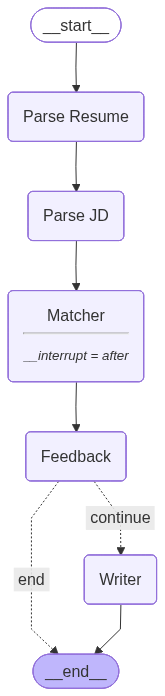

In [41]:
from langgraph.checkpoint.memory import MemorySaver

def parseResumeNode (state: StateSchema) -> StateSchema:
    sys_msg = SystemMessage (content=resumePrompt.format(schema=ResumeSchema.model_json_schema()))
    msg = HumanMessage (content=f"Resume text:\n\n{state['resume_text']}")

    response = resume_llm.invoke ([sys_msg, msg])
    return {'parsed_resume': response}

def parseJdNode (state:StateSchema) -> StateSchema:
    sys_msg = SystemMessage (content=jdPrompt.format(schema=JDSchema.model_json_schema()))
    msg = HumanMessage (content=f"Job Description text:\n\n{state['jd_text']}")

    response = jd_llm.invoke ([sys_msg, msg])
    return {'parsed_jd':response}


def matcher_node(state: StateSchema) -> StateSchema:
    """
    Runs the matcher and adds match_map to state
    """
    sys_msg = SystemMessage (content=matcher_system_prompt.format(schema=MatchMap.model_json_schema()))
    matcher_user_prompt = """Parsed Resume:
{parsed_resume}

Parsed Job Description:
{parsed_jd}

Create the MatchMap now."""

    msg = HumanMessage (content=matcher_user_prompt.format (parsed_resume=result['parsed_resume'], parsed_jd=result['parsed_jd']))
    response = matcher_llm.invoke ([sys_msg, msg])

    return {"match_map": response}

def writer_node (state:StateSchema) -> StateSchema:
    parsed_resume = state['parsed_resume']
    parsed_jd = state ['parsed_jd']
    match_map = state['match_map']
    job_title = state['parsed_jd'].job_title

    sys_msg = SystemMessage(content=writerPrompt.format (schema=CoverLetterDraft.model_json_schema(), job_title=job_title))

    msg = HumanMessage (f"""
Parsed Resume:
{parsed_resume}

Parsed JD:
{parsed_jd}

Match Map:
{match_map}

Write the full cover letter
""")
    
    response = writer_llm.invoke (input=[sys_msg, msg])
    return {'draft_letter':response}


def check_feedback (state:StateSchema) -> StateSchema:
    feedback = state['feedback']
    sys_msg = SystemMessage(content=feedbackPrompt.format(schema=ConditionState.model_json_schema()))
    msg = HumanMessage (content=f"The uer input is: {feedback}")
    response = condition_llm.invoke (input=[sys_msg, msg])
    return {'condition':response}

def condition_loop (state:StateSchema) -> Literal['continue', 'end']:
    condition = state['condition'].stop

    if condition:
        return 'end'
    else:
        return 'continue'
    


builder = StateGraph (state_schema=StateSchema)
builder.add_node ('Parse Resume', parseResumeNode)
builder.add_node ('Parse JD', parseJdNode)
builder.add_node ('Matcher', matcher_node)
builder.add_node ('Feedback', check_feedback)
builder.add_node ('Writer', writer_node)


builder.add_edge (START, 'Parse Resume')
builder.add_edge ('Parse Resume', 'Parse JD')
builder.add_edge ('Parse JD', 'Matcher')
builder.add_edge ('Matcher', 'Feedback')
builder.add_conditional_edges ('Feedback', condition_loop, {'continue':'Writer', 'end': END})
builder.add_edge ('Writer', END)

memory = MemorySaver ()
agent = builder.compile (interrupt_after=['Matcher'], checkpointer=memory)

display (Image (agent.get_graph().draw_mermaid_png()))

In [42]:
jd = """
Job Title: AI Engineer
Company: NeuroTech Innovations Ltd.
Location: Lagos, Nigeria (Hybrid/Remote Options)
Department: AI & Data Science
Employment Type: Full-Time
Salary Range: ₦15,000,000 – ₦25,000,000 per annum (commensurate with experience) + Benefits
Posted: January 2026
Job Overview
NeuroTech Innovations is a leading AI-driven startup in Nigeria, specializing in solutions for healthcare, finance, and agriculture. We're seeking a talented AI Engineer to join our team and drive the development of cutting-edge AI models. In this role, you'll build scalable AI systems, collaborate with cross-functional teams, and contribute to innovative projects that impact millions in emerging markets. If you're passionate about AI ethics, generative models, and real-world applications, we want to hear from you!
Key Responsibilities

Design, develop, and deploy machine learning models, including LLMs, computer vision, and predictive analytics, using frameworks like PyTorch, TensorFlow, and LangChain.
Optimize AI pipelines for production, focusing on efficiency, scalability, and edge deployment (e.g., via Kubernetes and AWS/GCP).
Conduct experiments with generative AI (e.g., diffusion models, GANs) and multimodal systems to solve domain-specific challenges.
Implement ethical AI practices, including bias detection, explainability, and compliance with regulations like Nigeria's Data Protection Act.
Collaborate with data engineers and product teams to integrate AI into applications, performing A/B testing and performance monitoring.
Stay updated on 2026 AI trends (e.g., federated learning, AI safety) and contribute to R&D initiatives.
Mentor junior engineers and participate in code reviews, ensuring best practices in MLOps.

Requirements

Bachelor's or Master's degree in Computer Science, AI, Data Science, or a related field.
3+ years of hands-on experience in AI/ML engineering.
Proficiency in Python and ML libraries (PyTorch/TensorFlow required; experience with Hugging Face, Scikit-learn preferred).
Strong understanding of deep learning architectures, NLP, and computer vision.
Experience with cloud platforms (AWS, Azure, GCP) and containerization (Docker).
Familiarity with big data tools (Spark) and version control (Git).
Excellent problem-solving skills and ability to work in agile environments.
Preferred: Certifications like AWS ML Specialty or publications in AI conferences.

Nice-to-Haves

Experience in African-centric AI applications (e.g., multilingual models for local languages).
Knowledge of reinforcement learning or AI for sustainability.
Open-source contributions or hackathon wins.

What We Offer

Competitive salary and equity options.
Health insurance, paid time off, and professional development stipend.
Flexible work environment with opportunities for remote collaboration.
Chance to work on impactful projects in a diverse, innovative team.

To apply, submit your resume and a cover letter highlighting your AI projects to careers@neurotech.ng. We are an equal opportunity employer.




"""

In [43]:
jd

"\nJob Title: AI Engineer\nCompany: NeuroTech Innovations Ltd.\nLocation: Lagos, Nigeria (Hybrid/Remote Options)\nDepartment: AI & Data Science\nEmployment Type: Full-Time\nSalary Range: ₦15,000,000 – ₦25,000,000 per annum (commensurate with experience) + Benefits\nPosted: January 2026\nJob Overview\nNeuroTech Innovations is a leading AI-driven startup in Nigeria, specializing in solutions for healthcare, finance, and agriculture. We're seeking a talented AI Engineer to join our team and drive the development of cutting-edge AI models. In this role, you'll build scalable AI systems, collaborate with cross-functional teams, and contribute to innovative projects that impact millions in emerging markets. If you're passionate about AI ethics, generative models, and real-world applications, we want to hear from you!\nKey Responsibilities\n\nDesign, develop, and deploy machine learning models, including LLMs, computer vision, and predictive analytics, using frameworks like PyTorch, TensorFlo

In [44]:
resume

'Felix Adebayo Lagos, Lagos, Nigeria | felix.adebayo@email.com | +234-123-456-7890 | \nlinkedin.com/in/felix-adebayo-ai | github.com/felixadebayo \nProfessional Summary \nDynamic AI Engineer with 5+ years of experience designing, developing, and deploying machine \nlearning models and AI systems. Expertise in generative AI, natural language processing (NLP), \ncomputer vision, and ethical AI frameworks. Proven track record in optimizing models for \nproduction, collaborating on cross-functional teams, and driving business impact through data-\ndriven solutions. Passionate about leveraging AI for sustainable development in emerging \nmarkets like Nigeria. \nSkills \n• Programming & Frameworks: Python, Java, PyTorch, TensorFlow, Scikit-learn, Hugging \nFace Transformers, LangChain, Keras \n• AI/ML Specialties: Deep Learning, NLP (e.g., LLMs like GPT-4, Llama), Computer Vision \n(OpenCV), Reinforcement Learning, Generative AI (GANs, Diffusion Models) \n• Tools & Platforms: AWS SageMaker, 

In [47]:
query = {
    'resume_text': resume,
    'jd_text': jd
}

config = {'configurable': {'thread_id': '1234'}}

response = agent.invoke (input=query, config=config)

In [48]:
response

{'resume_text': 'Felix Adebayo Lagos, Lagos, Nigeria | felix.adebayo@email.com | +234-123-456-7890 | \nlinkedin.com/in/felix-adebayo-ai | github.com/felixadebayo \nProfessional Summary \nDynamic AI Engineer with 5+ years of experience designing, developing, and deploying machine \nlearning models and AI systems. Expertise in generative AI, natural language processing (NLP), \ncomputer vision, and ethical AI frameworks. Proven track record in optimizing models for \nproduction, collaborating on cross-functional teams, and driving business impact through data-\ndriven solutions. Passionate about leveraging AI for sustainable development in emerging \nmarkets like Nigeria. \nSkills \n• Programming & Frameworks: Python, Java, PyTorch, TensorFlow, Scikit-learn, Hugging \nFace Transformers, LangChain, Keras \n• AI/ML Specialties: Deep Learning, NLP (e.g., LLMs like GPT-4, Llama), Computer Vision \n(OpenCV), Reinforcement Learning, Generative AI (GANs, Diffusion Models) \n• Tools & Platforms:

In [49]:
agent.get_state(config=config).next

('Feedback',)

In [50]:
response

{'resume_text': 'Felix Adebayo Lagos, Lagos, Nigeria | felix.adebayo@email.com | +234-123-456-7890 | \nlinkedin.com/in/felix-adebayo-ai | github.com/felixadebayo \nProfessional Summary \nDynamic AI Engineer with 5+ years of experience designing, developing, and deploying machine \nlearning models and AI systems. Expertise in generative AI, natural language processing (NLP), \ncomputer vision, and ethical AI frameworks. Proven track record in optimizing models for \nproduction, collaborating on cross-functional teams, and driving business impact through data-\ndriven solutions. Passionate about leveraging AI for sustainable development in emerging \nmarkets like Nigeria. \nSkills \n• Programming & Frameworks: Python, Java, PyTorch, TensorFlow, Scikit-learn, Hugging \nFace Transformers, LangChain, Keras \n• AI/ML Specialties: Deep Learning, NLP (e.g., LLMs like GPT-4, Llama), Computer Vision \n(OpenCV), Reinforcement Learning, Generative AI (GANs, Diffusion Models) \n• Tools & Platforms:

In [51]:
response['match_map'].model_dump()

{'overall_match_score': 85.0,
 'top_matches': [{'jd_element': 'Design, develop and deploy machine learning models, including LLMs and generative AI (e.g., diffusion models, GANs)',
   'jd_category': 'Technical Skills',
   'resume_evidence': 'Developed and deployed a generative AI chatbot using LangChain and Grok models, reducing customer support response time by 40% and handling 10,000+ queries monthly; fine‑tuned NLP models with Hugging Face Transformers.',
   'resume_section': 'work_experience',
   'strength_score': 0.88,
   'strong_match': True,
   'explanation': 'Candidate has end‑to‑end experience building, fine‑tuning, and deploying LLM‑based generative AI solutions in production, directly matching the JD requirement.',
   'suggested_phrasing': 'I have designed and deployed production‑ready generative AI solutions, such as a LangChain‑based chatbot that now handles over 10,000 queries monthly, demonstrating my ability to build LLM applications at scale.'},
  {'jd_element': 'Desig

In [52]:
feedback = "generate the cover letter"
agent.update_state (config=config, values={'feedback':feedback}, as_node='Matcher')

{'configurable': {'thread_id': '1234',
  'checkpoint_ns': '',
  'checkpoint_id': '1f137a99-ce14-64a8-800c-1d825ca0c11f'}}

In [53]:
response1 = agent.invoke (input=None, config=config)

In [54]:
response1

{'resume_text': 'Felix Adebayo Lagos, Lagos, Nigeria | felix.adebayo@email.com | +234-123-456-7890 | \nlinkedin.com/in/felix-adebayo-ai | github.com/felixadebayo \nProfessional Summary \nDynamic AI Engineer with 5+ years of experience designing, developing, and deploying machine \nlearning models and AI systems. Expertise in generative AI, natural language processing (NLP), \ncomputer vision, and ethical AI frameworks. Proven track record in optimizing models for \nproduction, collaborating on cross-functional teams, and driving business impact through data-\ndriven solutions. Passionate about leveraging AI for sustainable development in emerging \nmarkets like Nigeria. \nSkills \n• Programming & Frameworks: Python, Java, PyTorch, TensorFlow, Scikit-learn, Hugging \nFace Transformers, LangChain, Keras \n• AI/ML Specialties: Deep Learning, NLP (e.g., LLMs like GPT-4, Llama), Computer Vision \n(OpenCV), Reinforcement Learning, Generative AI (GANs, Diffusion Models) \n• Tools & Platforms:

In [55]:
print (response1['draft_letter'].full_letter)

Dear Hiring Team at NeuroTech Innovations,

I am excited to apply for the AI Engineer position at NeuroTech Innovations Ltd. With over five years of hands‑to‑hand experience designing, developing, and deploying large‑scale AI solutions—from generative LLM chatbots to computer‑vision pipelines—I bring the exact blend of technical depth and ethical stewardship that your mission to drive impact in healthcare, finance, and agriculture demands.

At TechInnovate Nigeria Ltd., I led the end‑to‑end creation of a LangChain‑based generative AI chatbot that now handles more than 10,000 queries each month, cutting customer‑support response time by 40%. The project required fine‑tuning Hugging Face Transformers, integrating the model into a Kubernetes‑orchestrated microservice, and deploying on AWS SageMaker. By automating the CI/CD workflow with Docker and Kubeflow, we reduced model go‑to‑market time by 50%, delivering a production‑ready LLM solution that aligns perfectly with NeuroTech’s requirem

In [56]:
if response['match_map'].strong_match:
    response_text = f"You are a strong match with score {response['match_map'].overall_match_score}\n{response['match_map'].explanation}"
else:
    response_text = f"You are not a strong match with score {response['match_map'].overall_match_score}\n{response['match_map'].explanation}"

In [57]:
response_text = response1['draft_letter'].full_letter

In [58]:
import requests
baseURl = "http://127.0.0.1:8000"

In [62]:
payload = {
    'resume':resume,
    'jd': jd
}
url = f"{baseURl}/write"
response = requests.post (url=url, json=payload)
response

<Response [200]>

In [63]:
print (response.json()['msg'])

You are a strong match with score 85.0
The candidate demonstrates strong technical expertise in generative AI, MLOps, cloud platforms, and ethical AI, with concrete achievements and African-focused projects that align closely with NeuroTech's needs.


In [64]:
payload = {
    'msg':'Continue to generate the cover letter'
}
url = f"{baseURl}/update"
response = requests.post (url=url, json=payload)
response

<Response [200]>

In [65]:
print (response.json()['msg'])

Dear Hiring Team at NeuroTech Innovations,

I am excited to apply for the AI Engineer role, drawn by NeuroTech’s mission to deliver ethical, high‑impact AI solutions across healthcare, finance, and agriculture in Nigeria. With over five years of hands‑on experience designing, deploying, and scaling generative AI systems—including a LangChain‑based chatbot that cut support response time by 40%—I am poised to accelerate your LLM initiatives from day one.

At TechInnovate Nigeria, I led the creation of a generative AI chatbot using LangChain and fine‑tuned large language models via Hugging Face. The project required rapid prototyping, rigorous testing, and seamless integration with existing fintech workflows. By orchestrating the model on AWS SageMaker and containerizing it with Docker and Kubernetes, we delivered a solution that handled more than 10,000 queries each month while maintaining 92% sentiment‑analysis accuracy. Parallel to this, I spearheaded ethical AI audits, securing an Eth